In [2]:
# loading packages
import numpy as np
import pandas as pd
from string import ascii_letters

In [3]:
# อ่านไฟล์ TSV
df = pd.read_csv(
    "C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset-773466_global-bleaching-and-environmental-data__v1.tsv",
    sep="\t"
)

# บันทึกเป็น CSV
df.to_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv", index=False)

In [4]:
# data visualization and missing values
import matplotlib.pyplot as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import seaborn as sns

In [5]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans

In [6]:
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree
from scipy.io import loadmat
from collections import defaultdict
from collections import Counter
from shapely.geometry import Point

In [7]:
sns.set_style('whitegrid') # One of the five seaborn themes
import warnings
warnings.filterwarnings('ignore') # To ignore some of seaborn warning msg

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
try:
    from sklearn.utils._testing import ignore_warnings
except ImportError:
    from sklearn.utils.testing import ignore_warnings

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LassoCV, RidgeCV

from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


import tkinter as tk 
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

In [9]:
df_old = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd'])
df_old

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [10]:
print(f"total number of rows and columns in the dataset: {len(df_old.columns)} columns, {len(df_old)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [11]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

In [12]:
nan_check(df_old)

,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
TSA_Minimum,5,0.1
SSTA_Frequency_Standard_Deviation,5,0.1
SSTA_FrequencyMax,5,0.1
SSTA_FrequencyMean,5,0.1
SSTA_DHW,5,0.1


In [13]:
df[['Depth' , 'Country_Name', 'Average_Bleaching' , 'SSTA' , 'ClimSST', 'Latitude_Degrees', 'Longitude_Degrees']].dtypes

Depth                float64
Country_Name          object
Average_Bleaching    float64
SSTA                  object
ClimSST               object
Latitude_Degrees     float64
Longitude_Degrees    float64
dtype: object

In [14]:
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    #print(year_counts)

    return df

df_Cleaned = Cleaning_date_to_year(df_old)

In [15]:
df_Cleaned.head()

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,2016
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52,2016
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49,2016
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36,2016
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56,2017


In [16]:
print(df_Cleaned['Date'].dt.year.drop_duplicates().sort_values())

1267    1998
3484    2000
3507    2001
1836    2002
473     2003
56      2004
16      2005
472     2006
83      2007
193     2008
62      2009
230     2010
542     2011
185     2012
188     2013
191     2014
215     2015
0       2016
4       2017
Name: Date, dtype: int32


In [17]:
def Select_data_some_datetime(df):

    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce')
    df = df[df['SSTA'] > 0]

    return df


df_Cleaned = Select_data_some_datetime(df_Cleaned)

In [18]:
print(f"Data in cleaned dataset: {len(df_Cleaned)}")
print(f"Data in original dataset: {len(df_old)}")
print(f"Percentage dropped: {(len(df_old) - len(df_Cleaned)) / len(df_old) * 100:.2f}%")
print(f"Percentage df_Cleaned: {(len(df_Cleaned)) / len(df_old) * 100:.2f}%")

Data in cleaned dataset: 6112
Data in original dataset: 9665
Percentage dropped: 36.76%
Percentage df_Cleaned: 63.24%


In [19]:
#Renaming columns
df_model = df_Cleaned.rename(columns={"Country_Name": "Country", "Depth": "Depth_m", "Average_Bleaching": "Average_Bleaching_percent"})

#Transforming column datatypes
df_model['ClimSST'] = pd.to_numeric(df_model['ClimSST'],errors='coerce')
df_model['Average_Bleaching_percent'] = pd.to_numeric(df_model['Average_Bleaching_percent'],errors='coerce')

In [20]:
nan_check(df_model)

,Total,%
City_Town_3,5511,90.2
City_Town_2,3142,51.4
City_Town,289,4.7
State_Island_Province,25,0.4
SSTA_Minimum,3,0.0
ID,0,0.0
TSA_Minimum,0,0.0
SSTA_FrequencyMax,0,0.0
SSTA_FrequencyMean,0,0.0
SSTA_DHW,0,0.0


In [21]:
#Fill NA into the data object
df_model.fillna(method ='ffill', inplace = True)

#Count of Null Values In the Data
df_model.isnull().sum().sort_values(ascending = False).head(35)

City_Town_3                          6
City_Town_2                          2
ID                                   0
TSA_Minimum                          0
SSTA_Frequency_Standard_Deviation    0
SSTA_FrequencyMax                    0
SSTA_FrequencyMean                   0
SSTA_DHW                             0
SSTA_DHW_Standard_Deviation          0
SSTA_DHWMax                          0
SSTA_DHWMean                         0
TSA                                  0
TSA_Standard_Deviation               0
TSA_Mean                             0
TSA_Maximum                          0
SSTA_Maximum                         0
TSA_Frequency                        0
TSA_Frequency_Standard_Deviation     0
TSA_FrequencyMax                     0
TSA_FrequencyMean                    0
TSA_DHW                              0
TSA_DHW_Standard_Deviation           0
TSA_DHWMax                           0
TSA_DHWMean                          0
SSTA_Frequency                       0
SSTA_Mean                

In [22]:
df_model[['SSTA', 'Depth_m', 'ClimSST', 'Latitude_Degrees', 'Longitude_Degrees', 'Average_Bleaching_percent']].dtypes

SSTA                         float64
Depth_m                      float64
ClimSST                      float64
Latitude_Degrees             float64
Longitude_Degrees            float64
Average_Bleaching_percent    float64
dtype: object

In [23]:
num_object = df_model.select_dtypes(exclude=['number']).columns
num_object

Index(['Ocean', 'Realm', 'Ecoregion', 'Country', 'State_Island_Province',
       'City_Town', 'City_Town_2', 'City_Town_3', 'Date'],
      dtype='object')

In [24]:
# Drop the categorical variables existing in the Data
df_correlation = df_model.drop(["ID", "Realm", "Ecoregion", "Country" ,"State_Island_Province", "City_Town","City_Town_2", "City_Town_3", "Date", "Date2"],axis=1)

In [25]:
df_numeric = df_correlation.select_dtypes(include=['number'])

#Find highly correlated pairs
corr_matrix = df_numeric.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
#print(upper_tri)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(to_drop)
print(len(to_drop))

['Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']
15


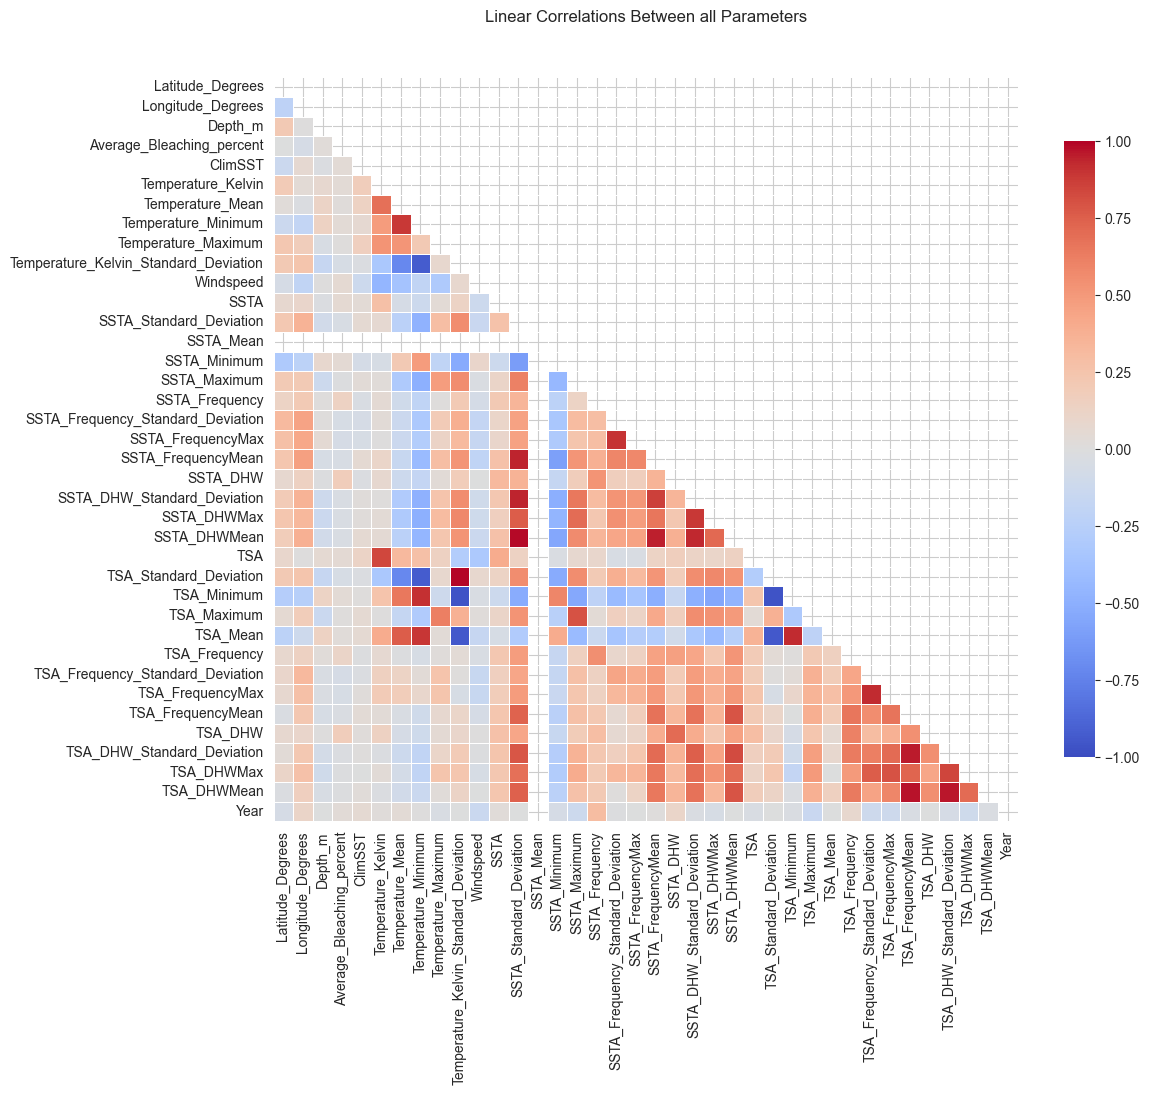

In [26]:
def Linear_Correlation(corr_matrix):
    # สร้าง mask เพื่อซ่อนครึ่งบน
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(12,10))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Linear Correlations Between all Parameters", pad=40)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.show()
    
Linear_Correlation(df_numeric.corr())

## 

## Preprocessing model

In [27]:
df_preprocessed = df_model.drop([
"Ocean","Temperature_Kelvin","Temperature_Mean", "Temperature_Minimum", "Temperature_Maximum", "Temperature_Kelvin_Standard_Deviation",
"Windspeed", "SSTA_Standard_Deviation", "SSTA_Mean", "SSTA_Minimum", "SSTA_Maximum", "SSTA_Frequency",
"SSTA_Frequency_Standard_Deviation","SSTA_FrequencyMax", "SSTA_FrequencyMean", "SSTA_DHW",
"SSTA_DHW_Standard_Deviation", "SSTA_DHWMax", "SSTA_DHWMean", "TSA", "TSA_Standard_Deviation",
"TSA_Minimum", "TSA_Maximum", "TSA_Mean","TSA_Frequency","TSA_Frequency_Standard_Deviation",
"TSA_FrequencyMax", "TSA_FrequencyMean","TSA_DHW", "TSA_DHW_Standard_Deviation", "TSA_DHWMax",
"TSA_DHWMean","Year"],axis=1)

In [28]:
df_wanted_columns = ['Average_Bleaching_percent' , 'SSTA' , 'Depth_m' , 'Latitude_Degrees' , 'Longitude_Degrees' , 'ClimSST']
nan_check(df_preprocessed[df_wanted_columns])

,Total,%
Average_Bleaching_percent,0,0.0
SSTA,0,0.0
Depth_m,0,0.0
Latitude_Degrees,0,0.0
Longitude_Degrees,0,0.0
ClimSST,0,0.0


In [29]:
print(len(df_numeric.columns))
print(len(df_numeric.drop(to_drop, axis=1).columns))
df_for_experiment = df_numeric.drop(to_drop, axis=1)

38
23


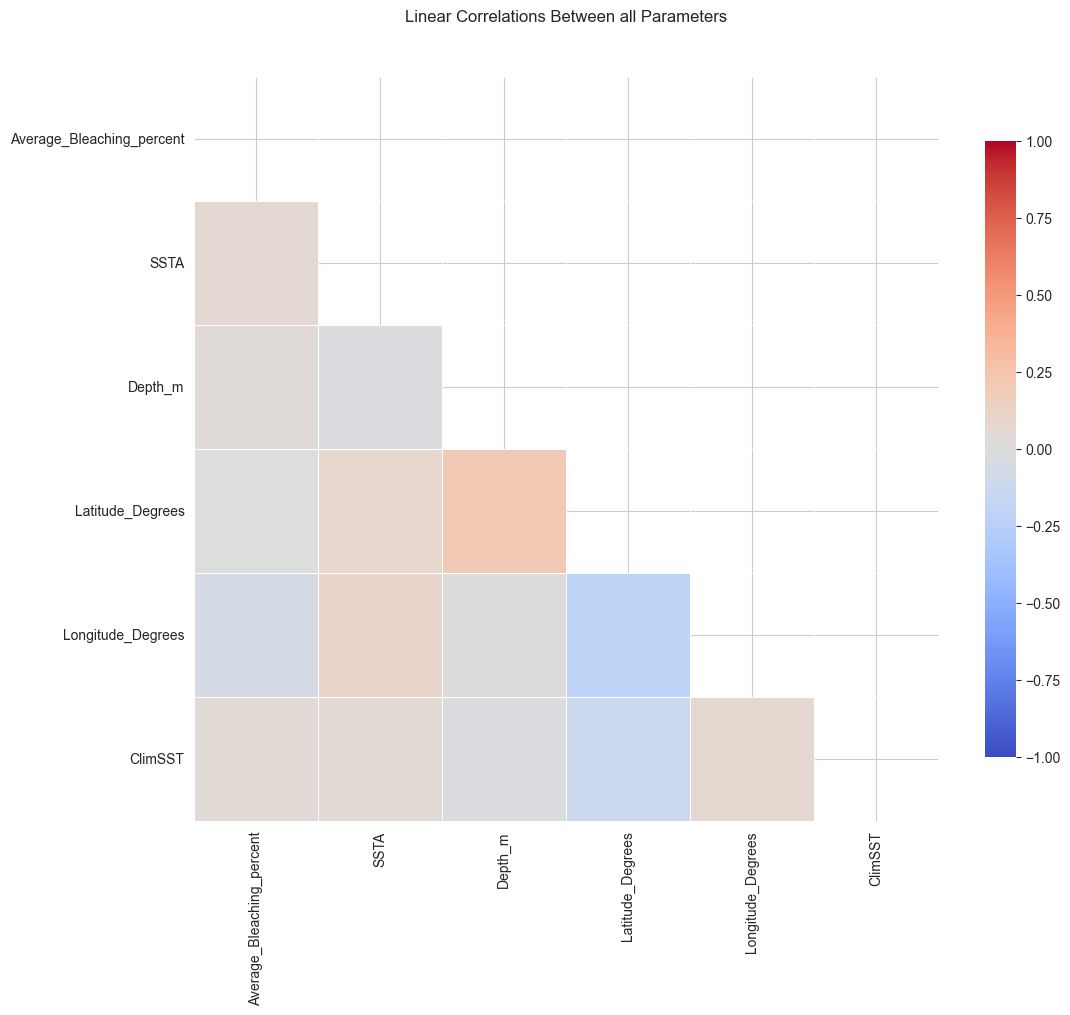

In [30]:
def Linear_Correlation(corr_matrix):
    # สร้าง mask เพื่อซ่อนครึ่งบน
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(12,10))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Linear Correlations Between all Parameters", pad=40)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.show()
    
Linear_Correlation(df_preprocessed[df_wanted_columns].corr())

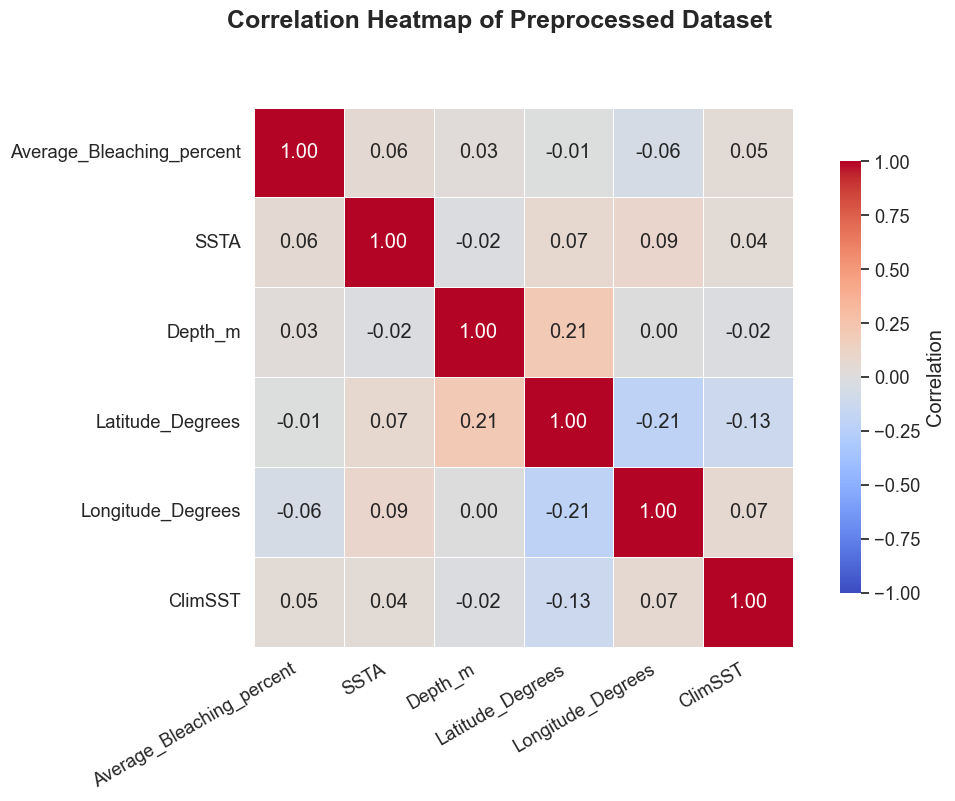

In [31]:
sns.set_theme(style="white", font_scale=1.2)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

corr = df_preprocessed[df_wanted_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

fig.suptitle(
    "Correlation Heatmap of Preprocessed Dataset",
    fontsize=18,
    fontweight="bold",
    x=0.5,
    y=1.02,
    ha="center"
)


plt.show()

________________________________________________________

##

## Random forest

In [32]:
RF_feature = df_preprocessed[['Latitude_Degrees', 'Longitude_Degrees', 'SSTA', 'Depth_m', 'ClimSST']]
RF_target = df_preprocessed['Average_Bleaching_percent']

RF_feature_values = RF_feature.values
RF_target_values = RF_target.values

In [33]:
RF_feature

,Latitude_Degrees,Longitude_Degrees,SSTA,Depth_m,ClimSST
0,-20.899833,149.407722,1.320000,4.0,297.78
1,-20.893056,149.421000,1.320000,5.0,297.78
2,-20.745806,149.472056,0.870000,6.0,298.17
3,-20.737694,149.464944,1.070000,5.0,298.21
4,-20.259361,148.814583,1.760000,2.0,296.48
...,...,...,...,...,...
9641,20.738889,107.058333,0.033333,3.2,262.15
9646,20.845833,107.177778,0.510000,3.0,299.80
9649,12.601722,53.817306,0.050000,6.0,301.40
9663,15.701611,42.391806,0.110000,9.0,304.39


In [34]:
RF_target_values

array([ 6.25,  8.75, 11.25, ...,  0.  ,  0.  ,  0.  ])

In [35]:
RF_feature_values

array([[-2.08998333e+01,  1.49407722e+02,  1.32000000e+00,
         4.00000000e+00,  2.97780000e+02],
       [-2.08930556e+01,  1.49421000e+02,  1.32000000e+00,
         5.00000000e+00,  2.97780000e+02],
       [-2.07458056e+01,  1.49472056e+02,  8.70000000e-01,
         6.00000000e+00,  2.98170000e+02],
       ...,
       [ 1.26017222e+01,  5.38173056e+01,  5.00000000e-02,
         6.00000000e+00,  3.01400000e+02],
       [ 1.57016111e+01,  4.23918056e+01,  1.10000000e-01,
         9.00000000e+00,  3.04390000e+02],
       [ 1.57016111e+01,  4.23918056e+01,  1.10000000e-01,
         5.00000000e+00,  3.04390000e+02]])

In [36]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_importance = pd.Series(importances, index=feature_train.columns)
    feature_importance = feature_importance.sort_values(ascending=False)
    
    return feature_importance

In [37]:
seed = 42
# Step 1: แบ่งข้อมูลออกเป็น train + validation และ test
X_train, X_test, y_train, y_test = train_test_split(RF_feature_values, RF_target_values, test_size=0.3, random_state=seed)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4278, 5), (4278,), (1834, 5), (1834,))

In [38]:
# with best parameters for 300 estimators
forest = RandomForestRegressor(max_features = 'sqrt', max_depth = 16, criterion = 'squared_error', bootstrap = False,
                            n_estimators = 300, random_state = seed)

forest.fit(X_train, y_train)


RandomForestRegressor(bootstrap=False, max_depth=16, max_features='sqrt',
                      n_estimators=300, random_state=42)

In [39]:
feature_importance_original = feature_importance(forest, RF_feature)
feature_importance_original.round(2)

Longitude_Degrees    0.24
SSTA                 0.22
Latitude_Degrees     0.22
ClimSST              0.21
Depth_m              0.11
dtype: float64

In [40]:
print(f"Score on training data: {forest.score(X_train, y_train)}")
y_test_pred = forest.predict(X_test)


test_mse = mean_squared_error(y_test, y_test_pred)
print("Test MSE:", test_mse.round(3))


test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse.round(3))

test_r2 = r2_score(y_test, y_test_pred)
print("Test R2 Score:", test_r2.round(3))

test_mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Absolute Error:", test_mae.round(3))


Score on training data: 0.9848985178741296
Test MSE: 70.758
Test RMSE: 8.412
Test R2 Score: 0.203
Mean Absolute Error: 3.311


In [41]:
print("Min y_test:", y_test.min())
print("Count zeros:", (y_test == 0).sum())
print("Count negative SSTA:", (df_preprocessed['SSTA'] < 0).sum())

Min y_test: 0.0
Count zeros: 1172
Count negative SSTA: 0


In [42]:
print("y_test shape:", y_test.shape)
print("y_test_pred shape:", y_test_pred.shape)

y_test shape: (1834,)
y_test_pred shape: (1834,)


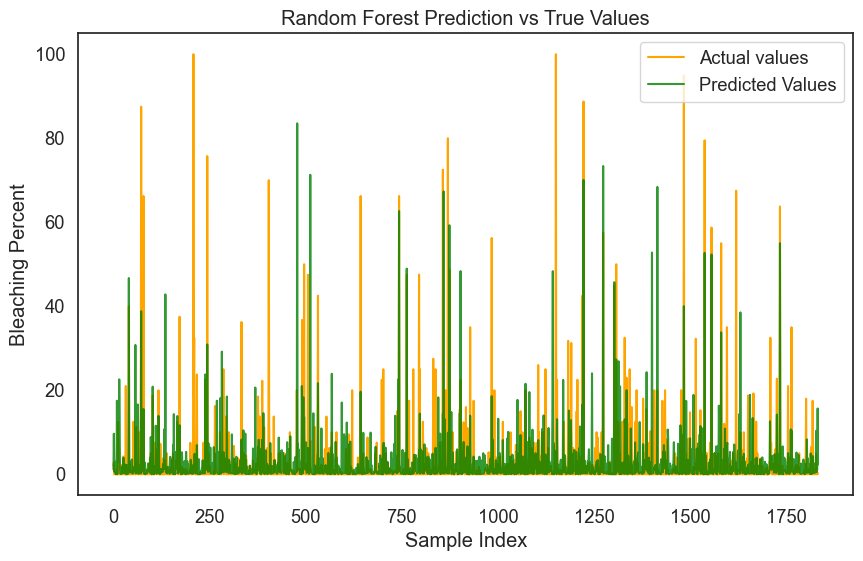

In [43]:
y_test = y_test.ravel()
y_test_pred = y_test_pred.ravel()

plt.figure(figsize=(10,6))

plt.plot(range(len(y_test)), y_test, 
            color='orange', alpha=1, label='Actual values')

plt.plot(range(len(y_test_pred)), y_test_pred, 
            color='green', alpha=0.8, label='Predicted Values')

plt.xlabel('Sample Index')
plt.ylabel('Bleaching Percent')
plt.title('Random Forest Prediction vs True Values')

plt.legend()
plt.show()

##

_____________________________________

## Data Analysis

In [45]:
df_preprocessed[df_wanted_columns].describe()

,Average_Bleaching_percent,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000
mean,2.795220,0.712972,6.471188,4.507037,58.370658,293.849604
std,9.634113,0.547437,3.467763,15.746898,97.062979,15.068575
min,0.000000,0.002500,0.100000,-28.162528,-179.859361,262.150000
25%,0.000000,0.300000,4.000000,-8.475972,-38.671806,297.910000
50%,0.000000,0.600000,6.000000,6.169861,104.126583,300.810000
75%,1.000000,1.000000,10.000000,17.901861,123.379028,302.150000
max,100.000000,4.610000,23.000000,34.098056,179.945333,304.390000


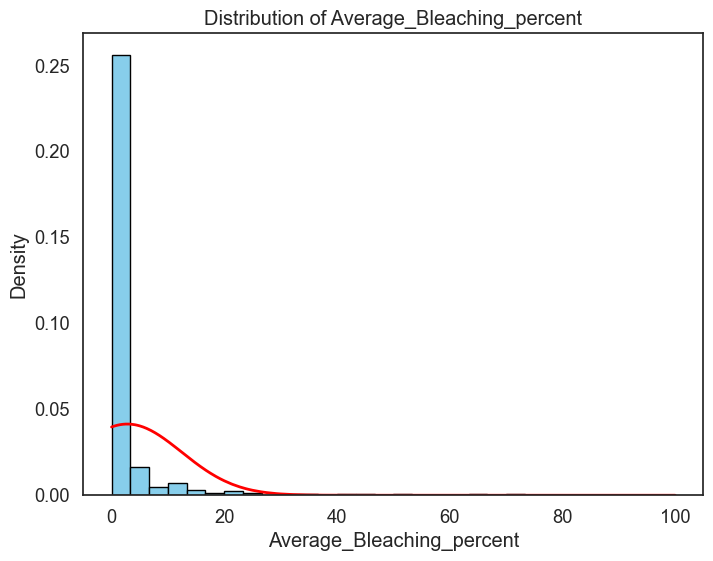

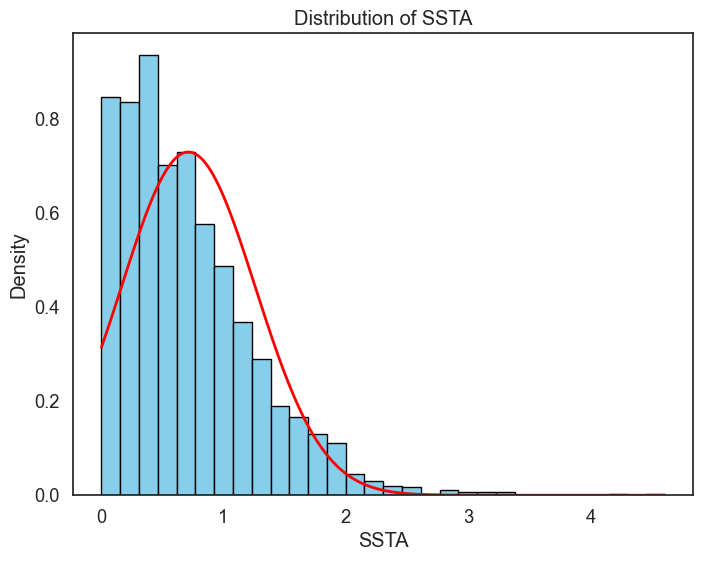

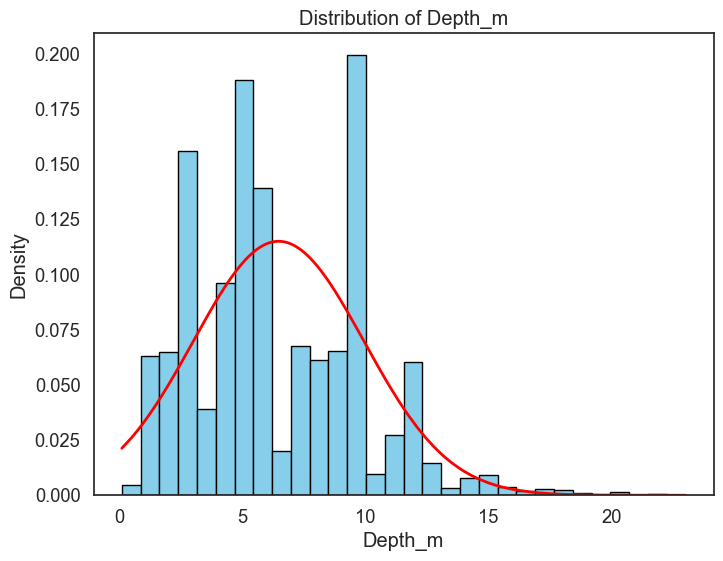

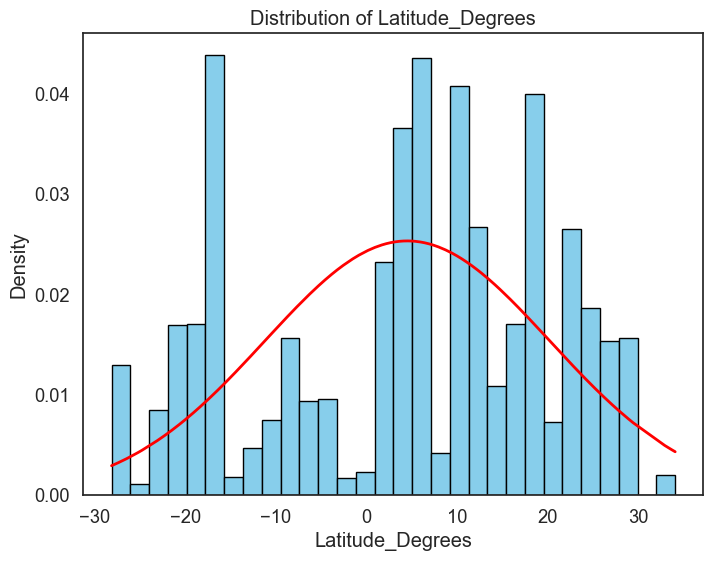

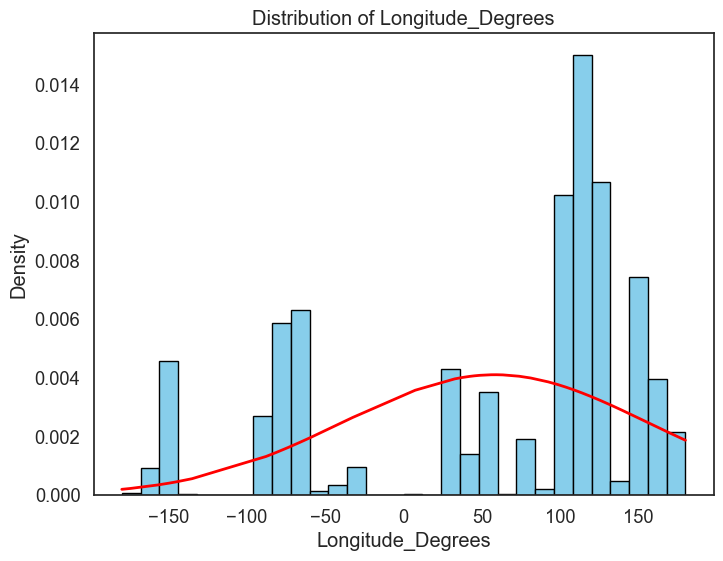

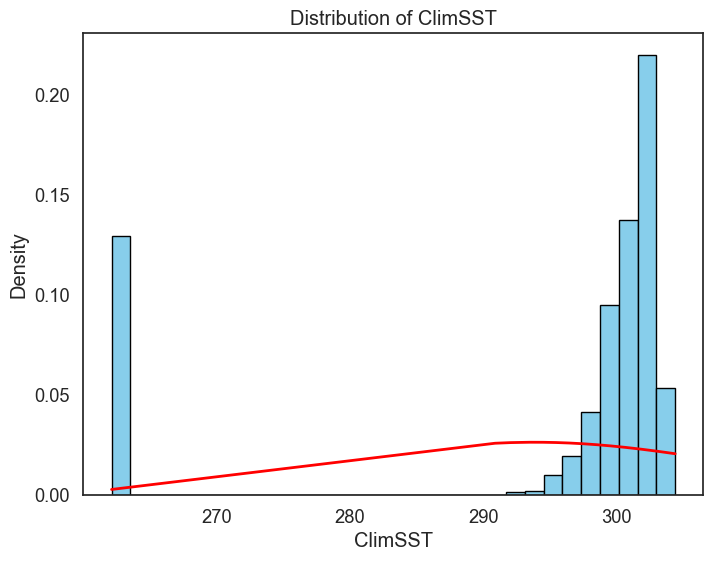

In [46]:
def plotting_distribution(data, columns):
    for col in columns:
        norm_fit = ss.norm.fit(data[col])
        datasortvalues = data[col].sort_values()
        plt.figure(figsize=(8,6))
        plt.hist(data[[col]], density=True, bins=30, color='skyblue', edgecolor='black')
        plt.plot(datasortvalues, ss.norm.pdf(datasortvalues, *norm_fit), color='red', linewidth=2)
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'Distribution of {col}')
        plt.show()


plotting_distribution(df_preprocessed, df_wanted_columns)

- 0       normal
- more than 0.5    moderate skew
- more than 1      strong skew

##

## zone technical

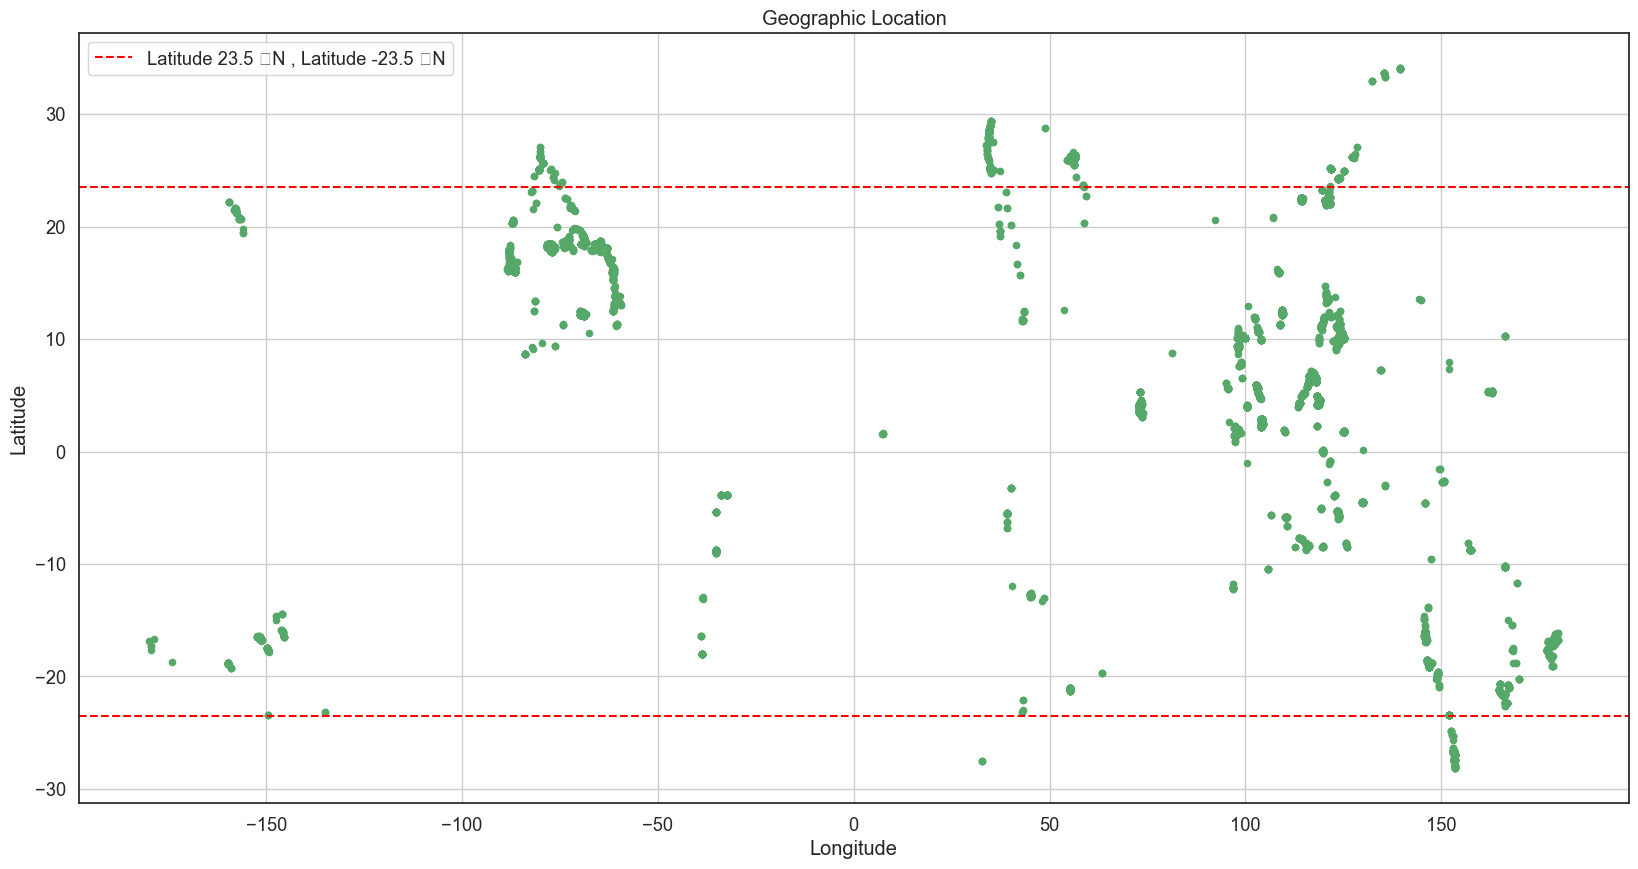

In [ ]:
plt.figure(figsize=(20,10))

plt.scatter(
    df_model["Longitude_Degrees"],
    df_model["Latitude_Degrees"],
    color="g",
    s=20
)

plt.axhline(y=23.5, color='red', linestyle='--', label='Latitude 23.5 ํN , Latitude -23.5 ํN')
plt.axhline(y=-23.5, color='red', linestyle='--')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Location")
plt.legend()

plt.grid(True)

plt.show()a

In [48]:
Zone_hot_climate = df_model[
    (df_model['Latitude_Degrees'] > -23.5) &
    (df_model['Latitude_Degrees'] < 23.5)
]

Zone_else = df_model[
    (df_model['Latitude_Degrees'] <= -23.5) | 
    (df_model['Latitude_Degrees'] >= 23.5)
]

print(f"zone hot climate: {len(Zone_hot_climate)}")
print(f"zone else: {len(Zone_else)}")


zone hot climate: 5267
zone else: 845


In [49]:
Zone_hot_climate[df_wanted_columns].describe().round(2)

,Average_Bleaching_percent,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,5267.00,5267.00,5267.00,5267.00,5267.00,5267.00
mean,2.97,0.70,6.41,2.76,57.21,294.58
std,10.08,0.53,3.53,13.70,100.94,14.77
min,0.00,0.00,0.10,-23.46,-179.86,262.15
25%,0.00,0.29,3.50,-8.71,-61.48,298.95
50%,0.00,0.58,6.00,5.61,104.51,301.21
75%,1.00,0.98,9.70,12.60,121.59,302.26
max,100.00,4.61,23.00,23.48,179.95,304.39


In [50]:
Zone_else[df_wanted_columns].describe().round(2)

,Average_Bleaching_percent,SSTA,Depth_m,Latitude_Degrees,Longitude_Degrees,ClimSST
count,845.00,845.00,845.00,845.00,845.00,845.00
mean,1.71,0.82,6.83,15.39,65.58,289.27
std,6.02,0.61,3.06,22.07,67.66,16.09
min,0.00,0.01,0.10,-28.16,-81.72,262.15
25%,0.00,0.35,5.00,24.35,34.52,262.15
50%,0.00,0.67,6.00,25.66,56.36,297.75
75%,0.50,1.12,10.00,28.35,127.34,299.62
max,56.25,2.99,17.00,34.10,153.56,303.67


## Random forest Latitude and Longitude divide topical zone

In [51]:
RF_feature_hot_climate = Zone_hot_climate[['Latitude_Degrees', 'Longitude_Degrees', 'SSTA', 'Depth_m', 'ClimSST']]
RF_target_hot_climate = Zone_hot_climate['Average_Bleaching_percent']

RF_feature_hot_climate_values = RF_feature_hot_climate.values
RF_target_hot_climate_values = RF_target_hot_climate.values


In [52]:
X_train_hot_climate, X_test_hot_climate, y_train_hot_climate, y_test_hot_climate = train_test_split(RF_feature_hot_climate_values, RF_target_hot_climate_values, test_size=0.3, random_state=seed)

X_train_hot_climate.shape, y_train_hot_climate.shape, X_test_hot_climate.shape, y_test_hot_climate.shape

((3686, 5), (3686,), (1581, 5), (1581,))

In [53]:
forest_hot_climate = RandomForestRegressor(
    max_features='sqrt',
    max_depth=16,
    criterion='squared_error',
    bootstrap=False,
    n_estimators=300,
    random_state=seed
)

forest_hot_climate.fit(X_train_hot_climate, y_train_hot_climate)

RandomForestRegressor(bootstrap=False, max_depth=16, max_features='sqrt',
                      n_estimators=300, random_state=42)

In [54]:
feature_importance_hot_climate = feature_importance(forest_hot_climate, RF_feature_hot_climate)
feature_importance_hot_climate

SSTA                 0.245946
Longitude_Degrees    0.230397
ClimSST              0.214847
Latitude_Degrees     0.198749
Depth_m              0.110062
dtype: float64

In [55]:
y_test_pred_hot_climate = forest_hot_climate.predict(X_test_hot_climate)
test_mse = mean_squared_error(y_test_hot_climate, y_test_pred_hot_climate)
print("Test MSE:", test_mse.round(3))


test_rmse = np.sqrt(mean_squared_error(y_test_hot_climate, y_test_pred_hot_climate))
print("Test RMSE:", test_rmse.round(3))

test_r2 = r2_score(y_test_hot_climate, y_test_pred_hot_climate)
print("Test R2 Score:", test_r2.round(3))

test_mae = mean_absolute_error(y_test_hot_climate, y_test_pred_hot_climate)
print("Mean Absolute Error:", test_mae.round(3))

Test MSE: 71.923
Test RMSE: 8.481
Test R2 Score: 0.064
Mean Absolute Error: 3.452


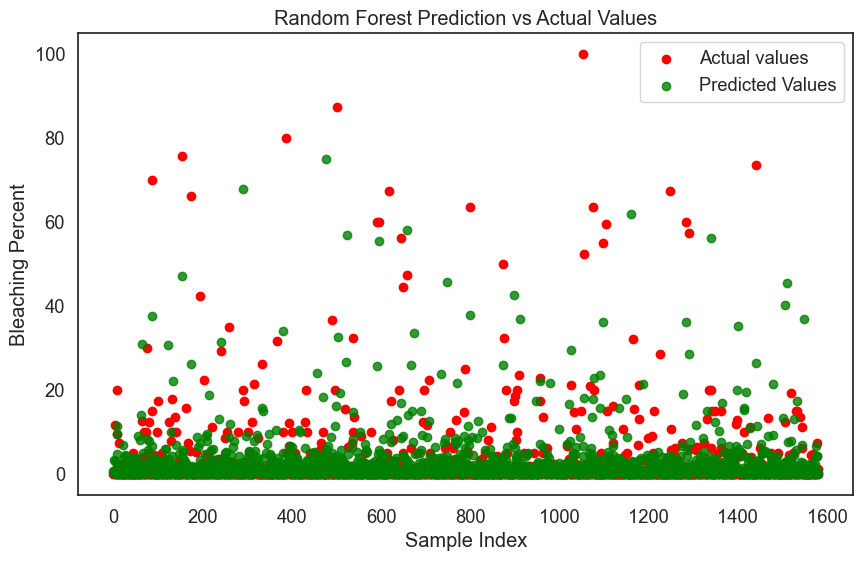

In [56]:
y_test = y_test_hot_climate.ravel()
y_test_pred = y_test_pred_hot_climate.ravel()

plt.figure(figsize=(10,6))

plt.scatter(range(len(y_test)), y_test, 
            color='red', alpha=1, label='Actual values')

plt.scatter(range(len(y_test_pred)), y_test_pred_hot_climate, 
            color='green', alpha=0.8, label='Predicted Values')

plt.xlabel('Sample Index')
plt.ylabel('Bleaching Percent')
plt.title('Random Forest Prediction vs Actual Values')

plt.legend()
plt.show()

##

_______________________________________________________

##

## High and Low bleaching using divide to Average_Bleaching percent

Text(0.5, 1.0, 'Geographic Location Hight Bleaching')

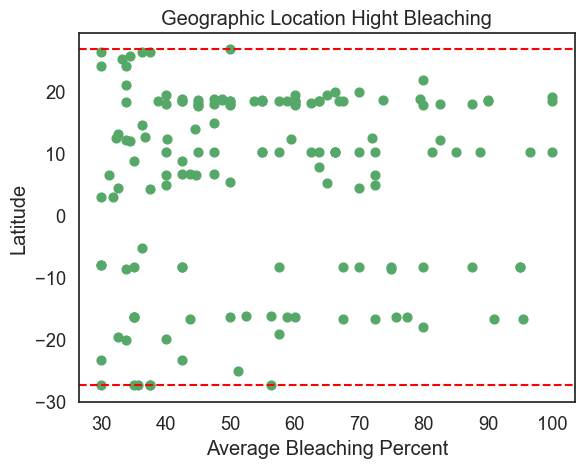

In [57]:
High_bleaching = df_preprocessed[df_preprocessed['Average_Bleaching_percent'] >= 30]
plt.scatter(
    High_bleaching['Average_Bleaching_percent'],
    High_bleaching['Latitude_Degrees'],
    color="g",
    s=40
)

plt.axhline(y=High_bleaching['Latitude_Degrees'].min(), color='red', linestyle='--', label='Latitude 23.5 ํN , Latitude -23.5 ํN')
plt.axhline(y=High_bleaching['Latitude_Degrees'].max(), color='red', linestyle='--')

plt.xlabel("Average Bleaching Percent")
plt.ylabel("Latitude")
plt.title("Geographic Location Hight Bleaching")

In [58]:
High_bleaching.describe().round(2)

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth_m,Average_Bleaching_percent,ClimSST,SSTA
count,151.00,151.00,151.00,151,151.00,151.00,151.00,151.00,151.00
mean,7354.97,5.58,26.78,2011-02-02 10:58:00.794702080,20106212.20,6.94,55.08,296.65,0.86
min,145.00,-27.52,-156.87,2003-11-06 00:00:00,20031106.00,1.00,30.00,262.15,0.01
25%,4851.50,-8.34,-69.49,2006-02-23 00:00:00,20060223.00,4.00,39.38,298.94,0.36
50%,7727.00,10.12,98.77,2010-07-15 00:00:00,20100715.00,6.00,50.00,300.82,0.70
75%,10463.50,18.32,117.91,2016-04-18 00:00:00,20160418.00,10.00,67.50,302.06,1.33
max,12766.00,26.70,179.24,2017-12-16 00:00:00,20171216.00,16.70,100.00,303.14,3.31
std,3873.20,15.32,103.11,NaN,46570.81,3.66,18.94,12.05,0.66


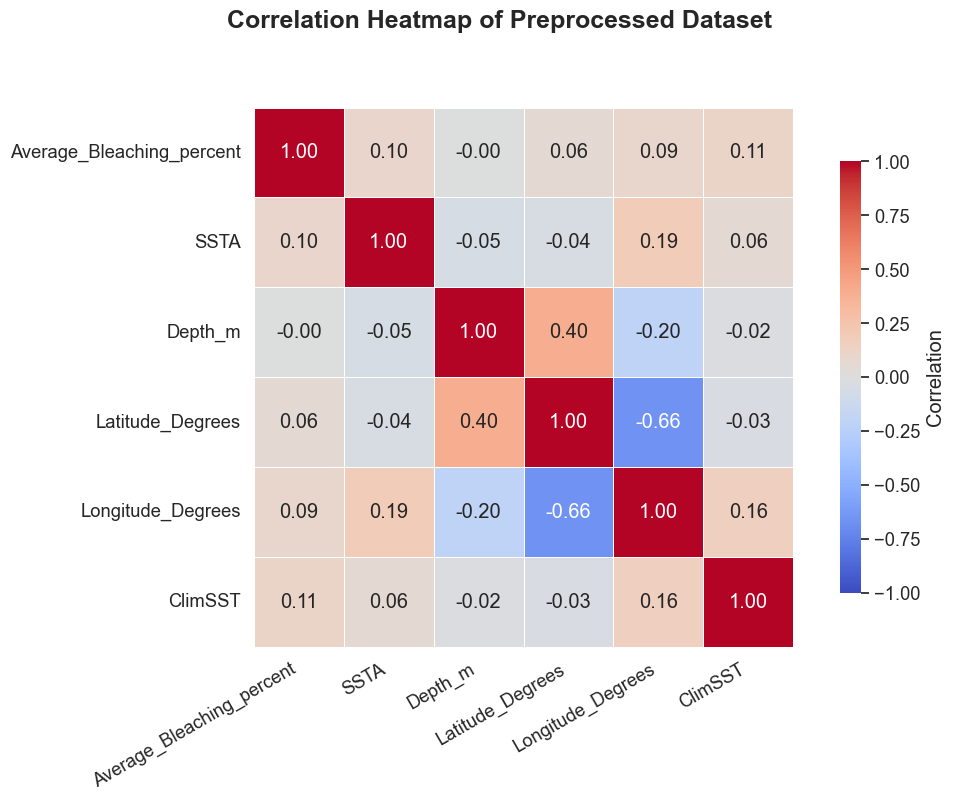

In [59]:
def Correlation_mretix(data, columns):
    sns.set_theme(style="white", font_scale=1.2)

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    corr = data[columns].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        square=True,
        cbar_kws={
            "shrink": 0.8,
            "label": "Correlation"
        }
    )

    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)

    fig.suptitle(
        "Correlation Heatmap of Preprocessed Dataset",
        fontsize=18,
        fontweight="bold",
        x=0.5,
        y=1.02,
        ha="center"
    )


    plt.show()
    
Correlation_mretix(High_bleaching, df_wanted_columns)

Text(0.5, 1.0, 'Geographic Location Low Bleaching')

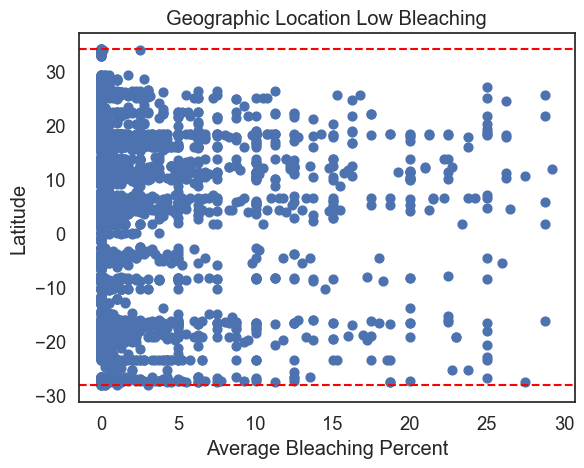

In [60]:
Low_bleaching = df_preprocessed[df_preprocessed['Average_Bleaching_percent'] < 30]
plt.scatter(
    Low_bleaching['Average_Bleaching_percent'],
    Low_bleaching['Latitude_Degrees'],
    color="b",
    s=40
)

plt.axhline(y=Low_bleaching['Latitude_Degrees'].min(), color='red', linestyle='--', label='Latitude 23.5 ํN , Latitude -23.5 ํN')
plt.axhline(y=Low_bleaching['Latitude_Degrees'].max(), color='red', linestyle='--')

plt.xlabel("Average Bleaching Percent")
plt.ylabel("Latitude")
plt.title("Geographic Location Low Bleaching")

In [61]:
Low_bleaching.describe().round(2)

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth_m,Average_Bleaching_percent,ClimSST,SSTA
count,5961.00,5961.00,5961.00,5961,5961.00,5961.00,5961.00,5961.00,5961.00
mean,8080.46,4.48,59.17,2010-09-15 22:22:38.832410624,20102420.75,6.46,1.47,293.78,0.71
min,97.00,-28.16,-179.86,2003-01-23 00:00:00,20030123.00,0.10,0.00,262.15,0.00
25%,5770.00,-8.51,-35.13,2006-12-09 00:00:00,20061209.00,3.80,0.00,297.86,0.30
50%,8322.00,6.03,104.15,2010-07-28 00:00:00,20100728.00,6.00,0.00,300.81,0.60
75%,10629.00,17.83,123.39,2014-07-12 00:00:00,20140712.00,10.00,0.75,302.15,0.99
max,13077.00,34.10,179.95,2017-12-20 00:00:00,20171220.00,23.00,29.25,304.39,4.61
std,3085.15,15.76,96.78,NaN,42516.78,3.46,3.89,15.13,0.54


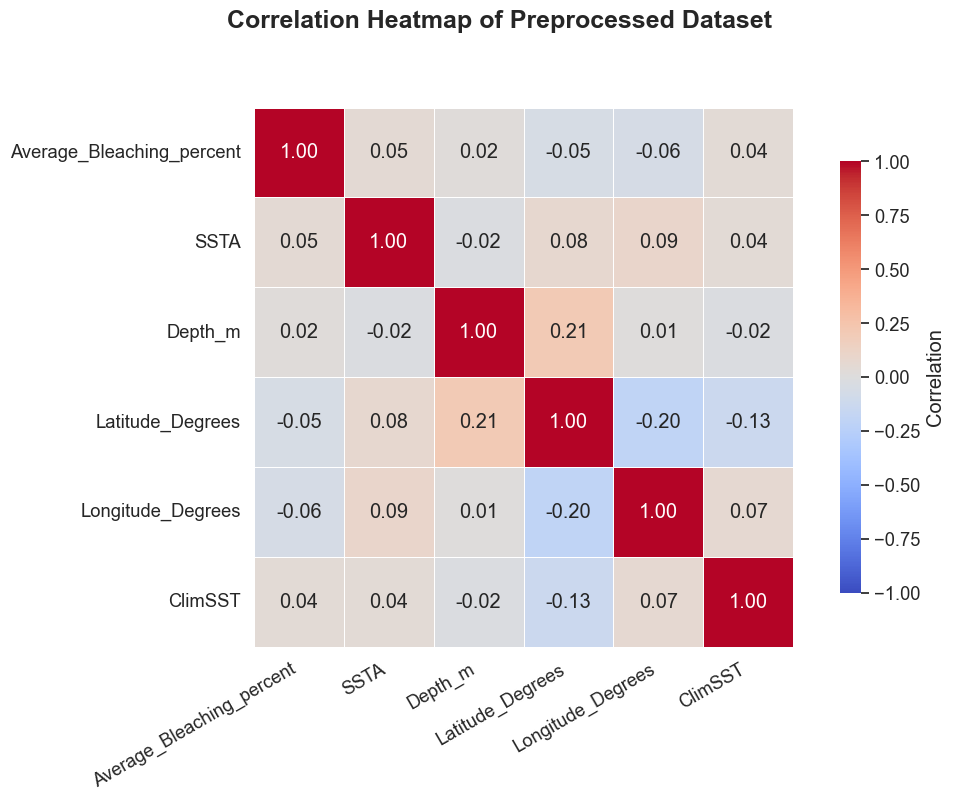

In [62]:
Correlation_mretix(Low_bleaching, df_wanted_columns)

_________________________________________________________________________

##  Hypothesis is SSTA have significiant for Average_Bleaching_percent

Text(0.5, 1.0, 'Geographic Location Hight Bleaching')

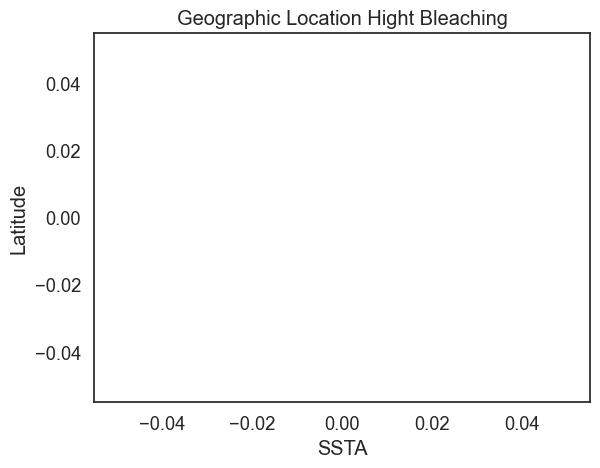

In [63]:
High_SSTA = df_preprocessed[df_preprocessed['SSTA'] >= 30]
plt.scatter(
    High_SSTA['SSTA'],
    High_SSTA['Latitude_Degrees'],
    color="g",
    s=40
)

plt.axhline(y=High_SSTA['Latitude_Degrees'].min(), color='red', linestyle='--', label='Latitude 23.5 ํN , Latitude -23.5 ํN')
plt.axhline(y=High_SSTA['Latitude_Degrees'].max(), color='red', linestyle='--')

plt.xlabel("SSTA")
plt.ylabel("Latitude")
plt.title("Geographic Location Hight Bleaching")

_________________________________________

## New Correlation

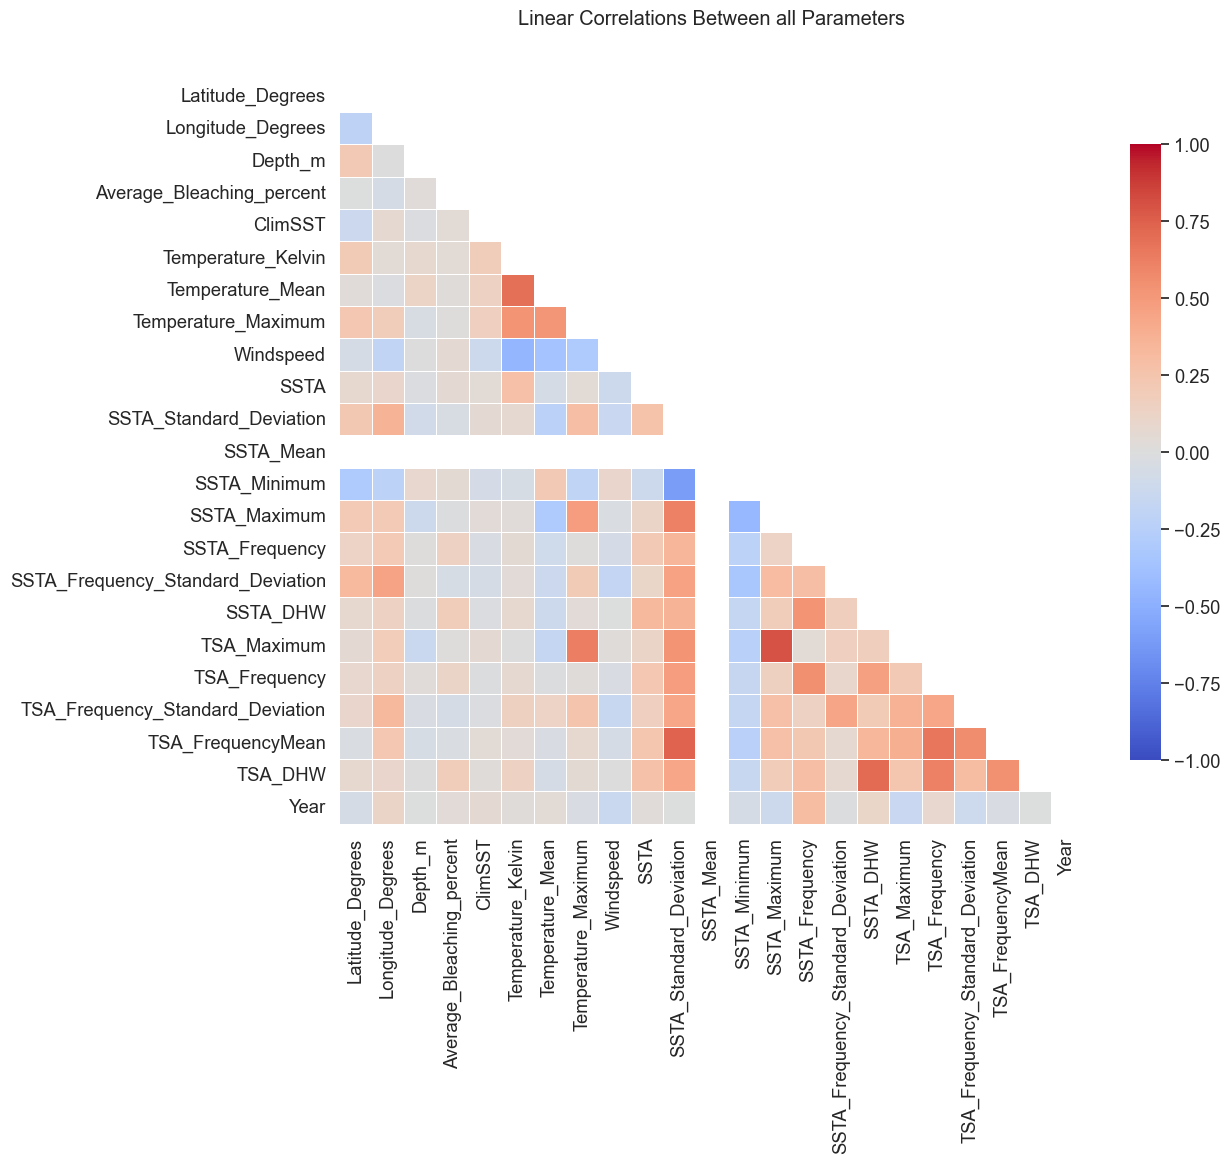

In [64]:
Linear_Correlation(df_for_experiment.corr())

In [65]:
df_for_experiment.corr()['Average_Bleaching_percent'].sort_values(ascending=False)

Average_Bleaching_percent            1.000000
SSTA_DHW                             0.176013
TSA_DHW                              0.174344
SSTA_Frequency                       0.136499
TSA_Frequency                        0.116205
SSTA                                 0.061674
Windspeed                            0.059772
SSTA_Minimum                         0.047890
ClimSST                              0.046032
Temperature_Kelvin                   0.041216
Year                                 0.034170
Depth_m                              0.027032
Temperature_Mean                     0.021123
Temperature_Maximum                  0.014305
TSA_Maximum                          0.013345
Latitude_Degrees                    -0.006710
SSTA_Maximum                        -0.012118
TSA_FrequencyMean                   -0.024203
SSTA_Standard_Deviation             -0.039344
SSTA_Frequency_Standard_Deviation   -0.049784
TSA_Frequency_Standard_Deviation    -0.056946
Longitude_Degrees                 

##

____________________________________________________________________

## Correlation and PCA for hypothesis
- I want to checking correlation variable beteween Average_Bleaching with other variable

 ______________________________________________

#### Rule experimnetal step
- Principle component analysis
- correaltion 
- selected ML model for prediction Average_Bleaching
- Evaluation

In [66]:
print(len(df_preprocessed.columns)) # Droped columns looking for paper research
print(len(df.columns)) # Oriiginal dataset
print(len(df_correlation.columns)) # Dataset for Correlation analysis

16
48
39
